<a href="https://colab.research.google.com/github/PietroMingardi/DataScience_Projects/blob/main/MLClassification_DecisionFatigue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/sonalshinde123/human-decision-fatigue-behavioral-dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset importing and usefull packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier


df = pd.read_csv("/content/drive/MyDrive/Test_ML/DecisionFatigue/human_decision_fatigue_dataset.csv")

# Dataset inspection

In [4]:
df.head(10)

,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Time_of_Day,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score,Fatigue_Level,System_Recommendation
0,7,28,7,2.30,5.8,Evening,0,2.4,0.000,2.6,15.6,Low,Continue
1,15,77,22,3.65,4.5,Afternoon,3,1.9,0.143,4.5,97.3,High,Take Break
2,11,57,23,3.67,6.8,Night,2,2.1,0.000,4.1,55.4,Moderate,Slow Down
3,8,39,10,2.39,5.3,Afternoon,1,1.0,0.000,2.3,29.7,Low,Continue
4,7,46,16,3.05,8.2,Night,1,2.8,0.000,3.9,19.1,Low,Continue
5,11,43,17,3.04,7.2,Afternoon,1,3.1,0.000,4.0,40.9,Moderate,Slow Down
6,11,57,19,4.31,6.2,Evening,2,1.0,0.000,3.3,54.2,Moderate,Slow Down
7,4,18,3,1.73,6.8,Afternoon,1,1.4,0.000,1.5,0.0,Low,Continue
8,8,35,8,0.79,6.0,Night,2,4.3,0.000,4.0,18.8,Low,Continue
9,3,9,2,1.11,8.0,Night,2,2.7,0.000,2.0,0.0,Low,Continue


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Hours_Awake             25000 non-null  int64  
 1   Decisions_Made          25000 non-null  int64  
 2   Task_Switches           25000 non-null  int64  
 3   Avg_Decision_Time_sec   25000 non-null  float64
 4   Sleep_Hours_Last_Night  25000 non-null  float64
 5   Time_of_Day             25000 non-null  object 
 6   Caffeine_Intake_Cups    25000 non-null  int64  
 7   Stress_Level_1_10       25000 non-null  float64
 8   Error_Rate              25000 non-null  float64
 9   Cognitive_Load_Score    25000 non-null  float64
 10  Decision_Fatigue_Score  25000 non-null  float64
 11  Fatigue_Level           25000 non-null  object 
 12  System_Recommendation   25000 non-null  object 
dtypes: float64(6), int64(4), object(3)
memory usage: 2.5+ MB


using the attribute .info we see that the dataset consists of 13 columns and 25000 rows. There appear to be no missing values ​​(we'll check whether these could be encoded in other ways). The encoding of the data type within each column appears to be consistent with the information represented in the column (e.g., there are no numeric columns encoded as strings). Unfortunately the dataset is accompied by very little metadata.


# We will try to classify the Fatigue Level variable

# Exploratory analysis

In [6]:
df.describe(include = "all")

,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Time_of_Day,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score,Fatigue_Level,System_Recommendation
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000,25000
unique,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,3,3
top,NaN,NaN,NaN,NaN,NaN,Afternoon,NaN,NaN,NaN,NaN,NaN,Low,Continue
freq,NaN,NaN,NaN,NaN,NaN,8827,NaN,NaN,NaN,NaN,NaN,11729,11728
mean,9.088280,45.433080,13.623480,2.918346,6.085956,NaN,1.897240,2.202736,0.031877,3.365784,40.579280,NaN,NaN
std,4.928093,25.611583,8.521595,0.942644,1.114586,NaN,1.430483,1.329868,0.057457,1.729092,36.704221,NaN,NaN
min,1.000000,0.000000,0.000000,0.500000,2.000000,NaN,0.000000,1.000000,0.000000,0.600000,0.000000,NaN,NaN
25%,5.000000,23.000000,7.000000,2.270000,5.300000,NaN,1.000000,1.000000,0.000000,1.900000,0.000000,NaN,NaN
50%,9.000000,45.000000,13.000000,2.910000,6.100000,NaN,2.000000,1.800000,0.000000,3.200000,34.650000,NaN,NaN
75%,13.000000,67.000000,20.000000,3.550000,6.900000,NaN,3.000000,3.100000,0.045000,4.600000,74.200000,NaN,NaN


## Visualize columns distributions

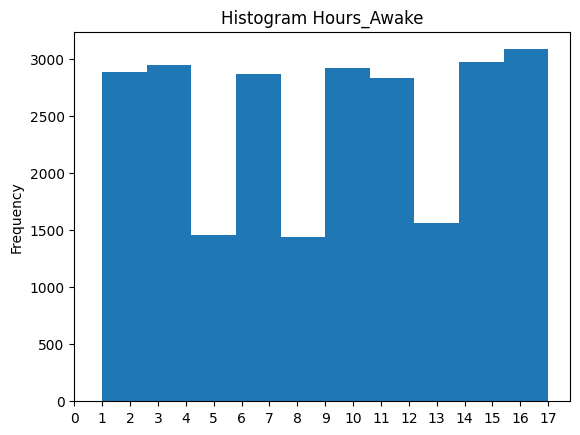

In [ ]:
df["Hours_Awake"].plot(kind = "hist")
plt.title("Histogram Hours_Awake")
plt.xticks([i for i in range(18)])
plt.show()

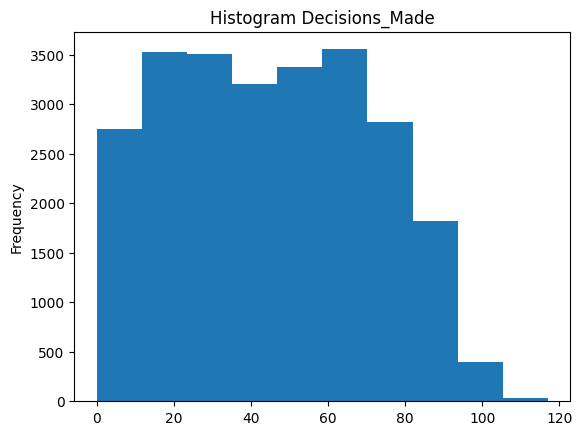

In [ ]:
df["Decisions_Made"].plot(kind = "hist")
plt.title("Histogram Decisions_Made")
plt.show()

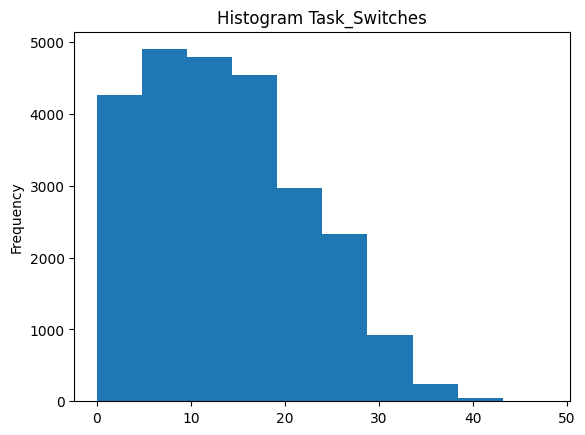

In [ ]:
df["Task_Switches"].plot(kind = "hist")
plt.title("Histogram Task_Switches")
plt.show()

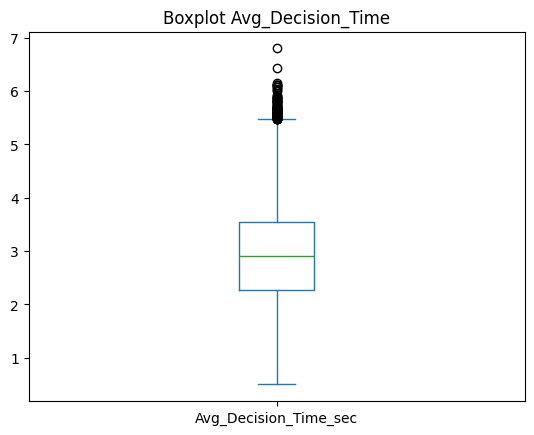

In [ ]:
df["Avg_Decision_Time_sec"].plot(kind = "box")
plt.title("Boxplot Avg_Decision_Time")
plt.show()

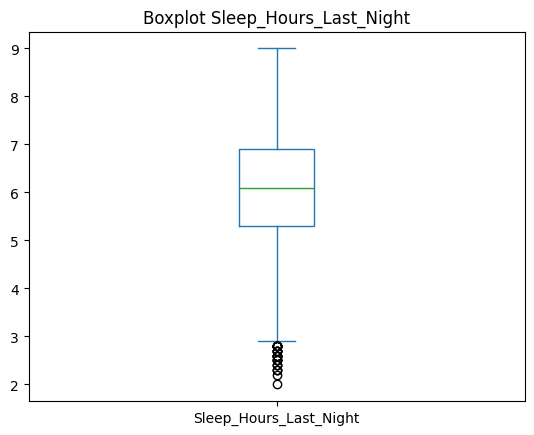

In [ ]:
df["Sleep_Hours_Last_Night"].plot(kind = "box")
plt.title("Boxplot Sleep_Hours_Last_Night")
plt.show()

  Time_of_Day  count
0   Afternoon   8827
1     Evening   6299
2     Morning   6044
3       Night   3830
------------------------------------------------------------------------------------------------------------------------


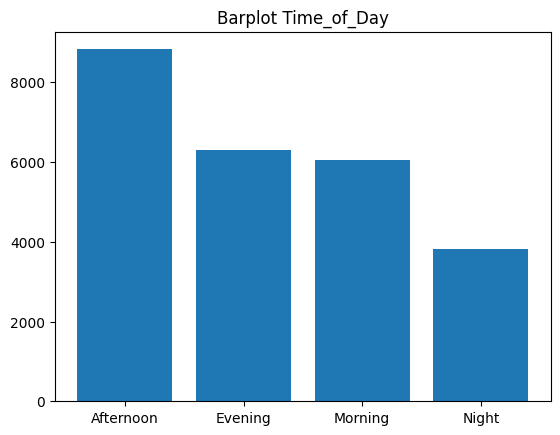

In [ ]:
Time_of_Day = df["Time_of_Day"].value_counts().reset_index()
print(Time_of_Day)
print("----"*30)
plt.bar(x = Time_of_Day["Time_of_Day"], height = Time_of_Day["count"])
plt.title("Barplot Time_of_Day")
plt.show()

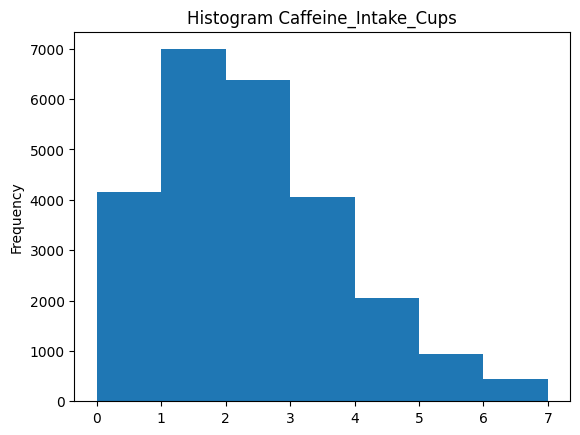

In [ ]:
df["Caffeine_Intake_Cups"].plot(
    kind="hist",
    bins=range(df["Caffeine_Intake_Cups"].min(),
               df["Caffeine_Intake_Cups"].max() + 2)
)
plt.title("Histogram Caffeine_Intake_Cups")
plt.show()

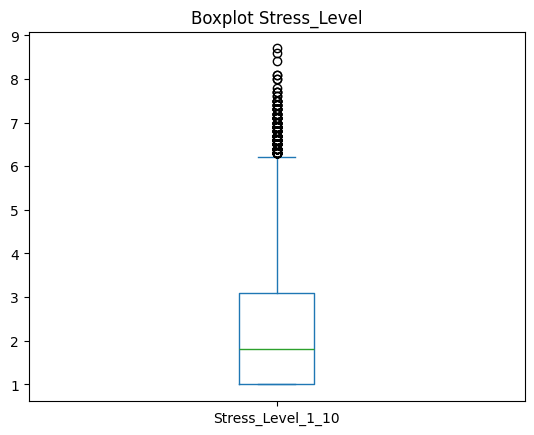

In [ ]:
df["Stress_Level_1_10"].plot(kind = "box")
plt.title("Boxplot Stress_Level")
plt.show()

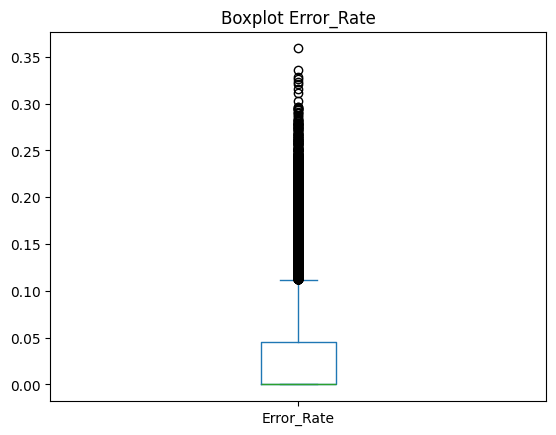

In [ ]:
df["Error_Rate"].plot(kind = "box")
plt.title("Boxplot Error_Rate")
plt.show()

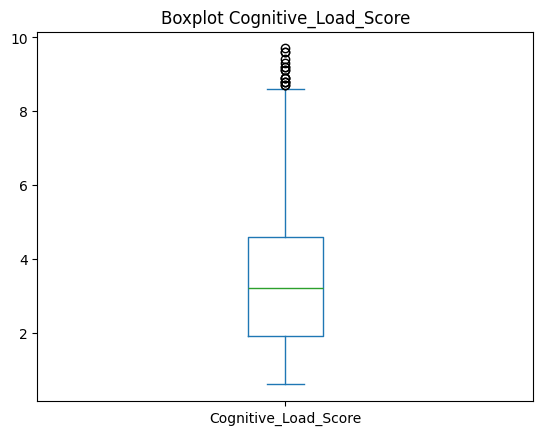

In [ ]:
df["Cognitive_Load_Score"].plot(kind = "box")
plt.title("Boxplot Cognitive_Load_Score")
plt.show()

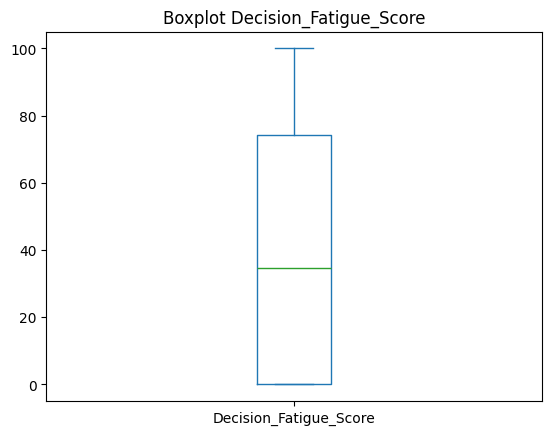

In [ ]:
df["Decision_Fatigue_Score"].plot(kind = "box")
plt.title("Boxplot Decision_Fatigue_Score")
plt.show()

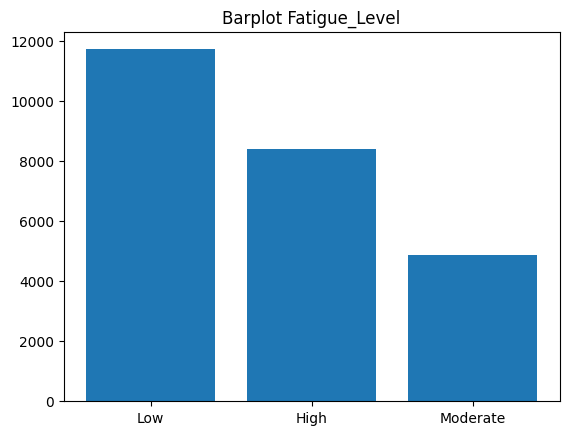

In [ ]:
Fatigue_Lvl = df["Fatigue_Level"].value_counts().reset_index()
plt.bar(x = Fatigue_Lvl["Fatigue_Level"], height = Fatigue_Lvl["count"])
plt.title("Barplot Fatigue_Level")
plt.show()

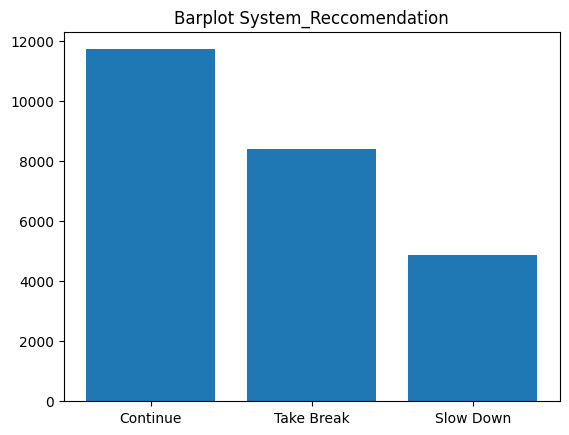

In [ ]:
System_Rec = df["System_Recommendation"].value_counts().reset_index()
plt.bar(x = System_Rec["System_Recommendation"], height = System_Rec["count"])
plt.title("Barplot System_Reccomendation")
plt.show()

From this initial EDA, we observe that the values in the dataset are consistent with the meaning of the corresponding columns. In particular, for those features where a valid range of values is defined, all observations fall within the expected range and no obvious outliers or impossible values are detected. Moreover, no missing values — including potential hidden missing values (e.g., values encoded as 0 or 99) — are observed, although the lack of metadata makes this assessment more challenging.

Regarding the target variable (Fatigue Level), a clear class imbalance is present. Specifically, the Low fatigue level is much more represented than the Moderate level, while the High level lies in between. This imbalance should be taken into account during the model implementation phase.

## Visualizzazioni Features/Target

<Axes: ylabel='Hours_Awake'>

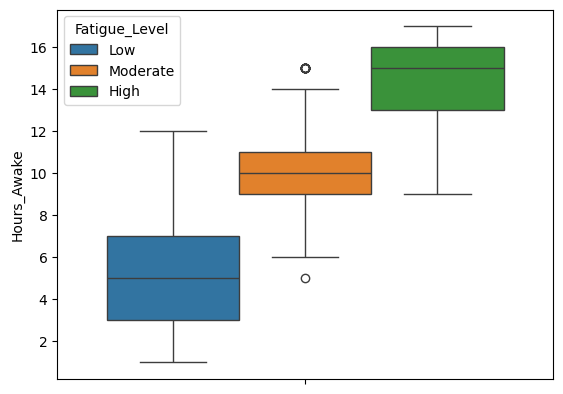

In [ ]:
sns.boxplot( data=df,
    y="Hours_Awake",
    hue="Fatigue_Level",
    hue_order = ["Low", "Moderate", "High"]
)

<Axes: ylabel='Decisions_Made'>

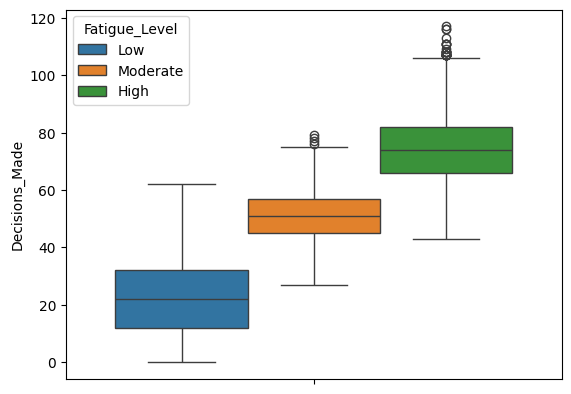

In [ ]:
sns.boxplot(data = df,
            y = "Decisions_Made",
            hue = "Fatigue_Level",
            hue_order = ["Low", "Moderate", "High"])

<Axes: ylabel='Task_Switches'>

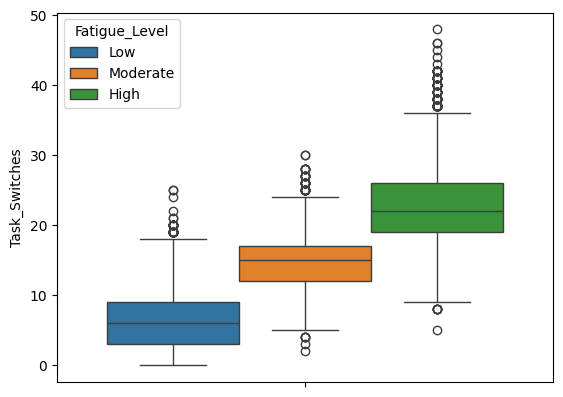

In [ ]:
sns.boxplot(data = df,
            y="Task_Switches",
            hue = "Fatigue_Level",
            hue_order = ["Low", "Moderate", "High"])

<Axes: ylabel='Avg_Decision_Time_sec'>

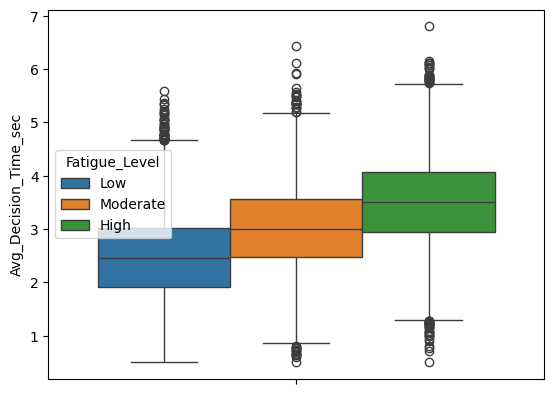

In [ ]:
sns.boxplot(data = df,
            y = "Avg_Decision_Time_sec",
            hue = "Fatigue_Level",
            hue_order = ["Low", "Moderate", "High"])

<Axes: ylabel='Sleep_Hours_Last_Night'>

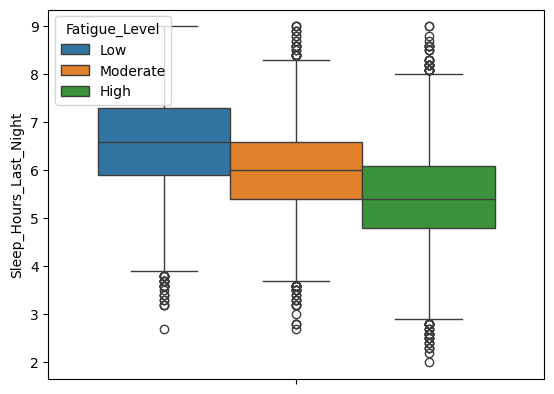

In [ ]:
sns.boxplot(data = df,
            y = "Sleep_Hours_Last_Night",
            hue = "Fatigue_Level",
            hue_order = ["Low", "Moderate", "High"])

<Axes: xlabel='Time_of_Day', ylabel='Count'>

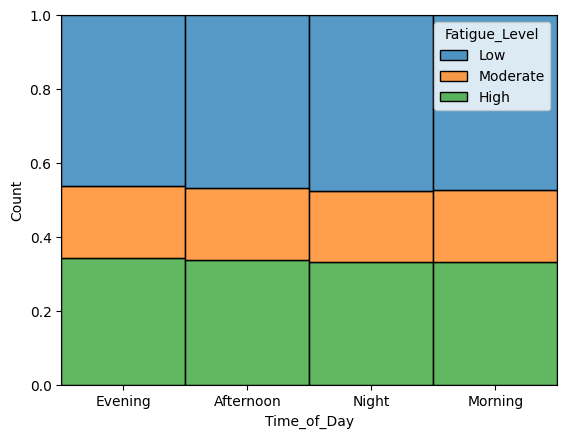

In [ ]:
sns.histplot(
    data=df,
    x="Time_of_Day",
    hue="Fatigue_Level",
    hue_order = ["Low", "Moderate", "High"],
    multiple="fill"
)

#we use relative frequencies in this plot, beacuse we have already see that there is imbalance among classes of the feature Time_of_Day

<Axes: xlabel='Caffeine_Intake_Cups', ylabel='Count'>

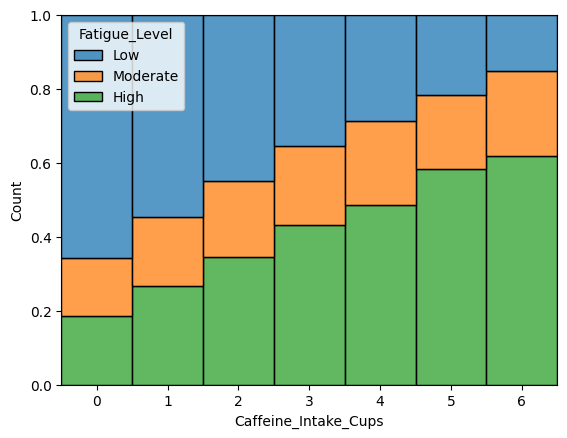

In [ ]:
sns.histplot(
    data=df,
    x="Caffeine_Intake_Cups",
    hue="Fatigue_Level",
    hue_order = ["Low", "Moderate", "High"],
    multiple="fill",
    discrete=True
) #in this case we use a histogram beacuse Caffeine_Intake_Cups is a discret vaiable with few values (range from 0 to 6)

<Axes: ylabel='Stress_Level_1_10'>

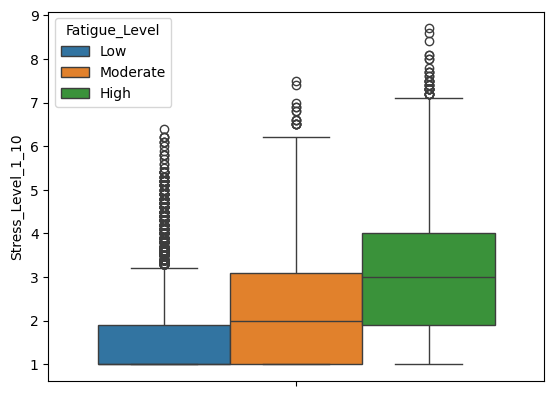

In [ ]:
sns.boxplot(data = df,
            y = "Stress_Level_1_10",
            hue = "Fatigue_Level",
            hue_order = ["Low", "Moderate", "High"])

<Axes: ylabel='Error_Rate'>

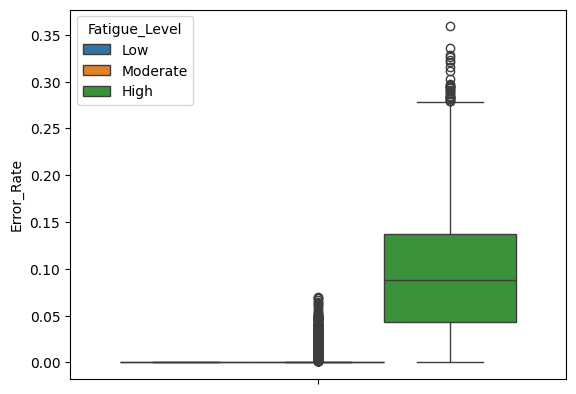

In [ ]:
sns.boxplot(data = df,
            y = "Error_Rate",
            hue = "Fatigue_Level",
            hue_order = ["Low", "Moderate", "High"])


<Axes: ylabel='Cognitive_Load_Score'>

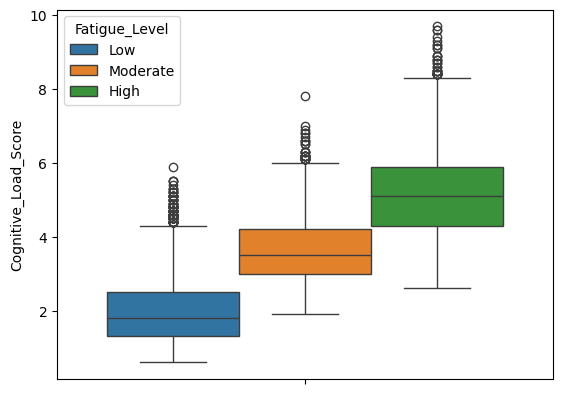

In [ ]:
sns.boxplot(data = df,
            y = "Cognitive_Load_Score",
            hue = "Fatigue_Level",
            hue_order = ["Low", "Moderate", "High"])

<Axes: ylabel='Decision_Fatigue_Score'>

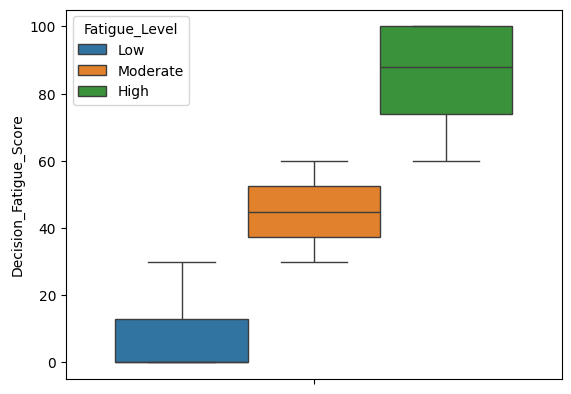

In [ ]:
sns.boxplot(data = df,
            y = "Decision_Fatigue_Score",
            hue = "Fatigue_Level",
            hue_order = ["Low", "Moderate", "High"])

<Axes: xlabel='System_Recommendation', ylabel='Count'>

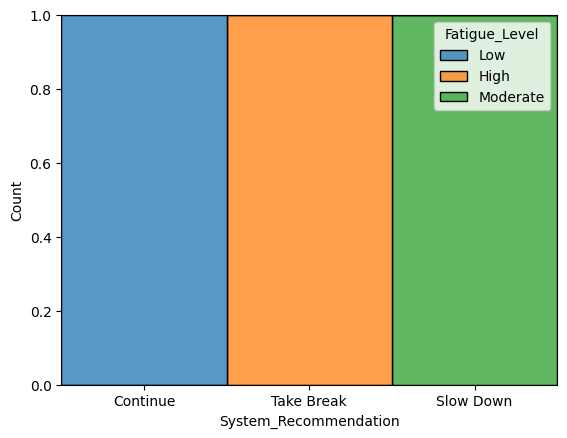

In [ ]:
sns.histplot(
    data=df,
    x="System_Recommendation",
    hue="Fatigue_Level",
    multiple="fill"
)

## Correlations

In [7]:
#selezioniamo le colonne numeriche
num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols.drop("Decision_Fatigue_Score") #eliminiamo la feature che non useremmo sicuramente
corr_mat = df[num_cols].corr(method="spearman") # we use spearman correlation since it does not assume linear relationships

<Axes: >

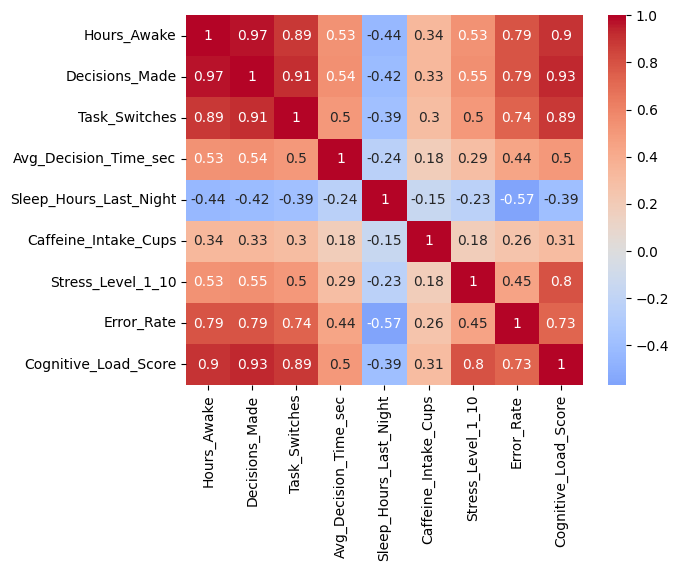

In [ ]:
sns.heatmap(
    corr_mat,
    cmap="coolwarm",
    center=0,
    annot=True
)

Comments:
- Many features in the dataset appear to separate the three classes of the Fatigue Level (our target variable) quite well (e.g., Hours_Awake, Decisions_Made, Task_Switches).

- For several features, we observe a monotonic relationship with the target variable, which is coherent with their semantic meaning. For instance, Hours_Awake shows a positive monotonic relationship with Fatigue Level (higher Hours_Awake → higher Fatigue Level), whereas Hours_Sleep_Last_Night exhibits a negative monotonic relationship (higher Hours_Sleep_Last_Night → lower Fatigue Level).

- Some features should definitely be removed (namely System_Recommendation and Decision_Fatigue_Score), as the plots clearly indicate that they are linear transformations of the target variable, leading to perfect class separation.

- One feature (Error_Rate) seems to separate the High Fatigue Level particularly well from the other two classes (Low and Moderate). Despite not beeing a perfect class separation, we do not know how and when Error_Rate and Fatigue_Level are measured, for this reason we will have a special care for this feature.

- Lastly, despite plots do not show anything strange, based on domain knowledge, we know that Cognitive_Load and Fatigue_Level are two very similar concepts. Again, the lack of metadata, does not allow us to know how Cognitive_Load and Fatigue_Level are operationalized and measured so, in a similar vein to Error_Rate, also for the Congnitive_Load_Score feature we will have a special care.

- Several numerical features exhibit high pairwise correlations, indicating a potential risk of multicollinearity.

# Features Selection

In [9]:
features_names = df.columns.drop(['Decision_Fatigue_Score', 'System_Recommendation', 'Fatigue_Level']) #selezioniamo tutte le colonne a parte quella di output e 2 che abbiamo
#identificato essere derivazione di quella di outcome

outcome_name = "Fatigue_Level"

In [10]:
X = df[features_names]
y = df[outcome_name]

# Train test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42) #splittiamo 70%-30% stratifichiamo su y dato che è sbilanciata

# Logistic Regression

###### we will implement a Logistic Regression. We will use the Ridge regolarization to mange the potentail risk of multicollinearity. Numeric features will be standardized to allow a comparison of the coefficients, to facilitate model convergence and beacause it is mandatory when using regolarization

In [12]:
#divide numeric features and the categorical one
num_feature = [i for i in X_train.columns if i != "Time_of_Day"]
cat_feature = ["Time_of_Day"]

In [ ]:
#define features scaling and one-hot encoding
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_feature),
        ("cat", OneHotEncoder(drop="first"), cat_feature)
    ]
)

In [ ]:
#define the pipeline to fit the Logistic Regression
baseline_pipeline_log = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        max_iter=1000
    ))
])

In [ ]:
#implement cross-validation (in this way we can avoid overfitting)
scores = cross_val_score(
    baseline_pipeline_log,
    X_train, y_train,
    cv=5, #5 pighe di folds
    scoring="f1_macro" #usiamo f1 per unbalanced target
)


scores.mean(), scores.std()

(np.float64(0.9926048451250375), np.float64(0.0013696376700788983))

**Comment**:

- this first Logistic Regression we implemented report a really high mean f1 score (0.993) with really little varabiability among folds (std_dev: 0.0014).
We are aware this dataset is simulated, anyway we prefer to perform a sanity check to ensure the result is not affected by the features (Cognitive_Load_Score and Error_Rate) we cannot ensure are "real" predictors of the target variable.

## Sanity check

In [ ]:
#define a function that allow us to modify the features in the training set and calculate the f1-score using a crossvalidation
def calcola_f1(features, outcome, columns_to_drop):
  X = features.copy() #make a copy of the original X_train
  X.drop(columns = columns_to_drop, inplace = True) #drop columns

  num_features = list(X.select_dtypes(include = "number").columns) #make a list with the names of the remaing columns
  cat_feature = ["Time_of_Day"] #the categorical feature

  preprocess_local = ColumnTransformer(
      transformers=[
          ("num", StandardScaler(), num_features),
          ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_feature)
      ],
      remainder="drop"
  )

  pipeline_local = Pipeline([
      ("preprocess", preprocess_local),
      ("clf", LogisticRegression(
          solver="lbfgs",
          penalty="l2",
          max_iter=1000
      ))
  ])

  scores_temp = cross_val_score(
    pipeline_local,
    X, outcome,
    cv=5,
    scoring="f1_macro"
)


  return scores_temp.mean(), scores_temp.std() #return mean F1 and std F1 between the 5 folds


In [ ]:
print("l'F1 medio totale é:", calcola_f1(X_train, y_train, [])[0])
print("l'F1 medio quando viene rimosso 'Error_Rate' é:", calcola_f1(X_train, y_train, ["Error_Rate"])[0])
print("l'F1 medio quando viene rimosso 'Cognitive_Load_Score' é:", calcola_f1(X_train, y_train, ["Cognitive_Load_Score"])[0])
print("l'F1 medio quando viene rimosso 'Error Rate' e Cognitive_Load_Score' é:", calcola_f1(X_train, y_train, ["Error_Rate", "Cognitive_Load_Score"])[0])

l'F1 medio totale é: 0.9926048451250375
l'F1 medio quando viene rimosso 'Error_Rate' é: 0.9939620282588594
l'F1 medio quando viene rimosso 'Cognitive_Load_Score' é: 0.9931755807976668
l'F1 medio quando viene rimosso 'Error Rate' e Cognitive_Load_Score' é: 0.9943957136332005


F1 remains similar also eliminating the two features, so results do not seem due to the presence of these two features. Not showing clearly signs of data leakage we will keep these two features in the model.

# Predictions on the test set

In [ ]:
#we can use the first model we tested
baseline_pipeline_log.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Hours_Awake',
                                                   'Decisions_Made',
                                                   'Task_Switches',
                                                   'Avg_Decision_Time_sec',
                                                   'Sleep_Hours_Last_Night',
                                                   'Caffeine_Intake_Cups',
                                                   'Stress_Level_1_10',
                                                   'Error_Rate',
                                                   'Cognitive_Load_Score']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Time_of_Day'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred = baseline_pipeline_log.predict(X_test)

In [ ]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      2521
         Low       1.00      1.00      1.00      3519
    Moderate       0.99      0.99      0.99      1460

    accuracy                           1.00      7500
   macro avg       0.99      0.99      0.99      7500
weighted avg       1.00      1.00      1.00      7500



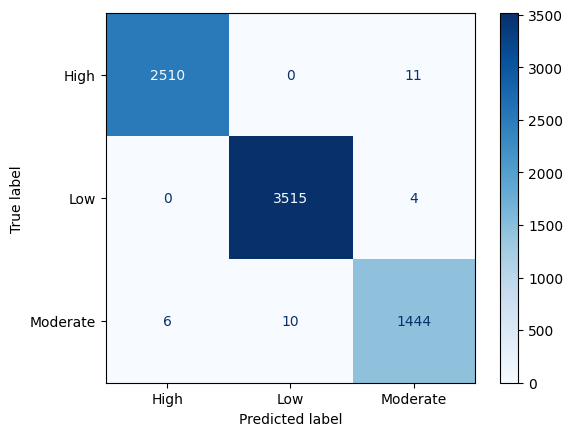

In [ ]:
#Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
        baseline_pipeline_log,
        X_test,
        y_test,
        cmap=plt.cm.Blues
    )
#print(disp.confusion_matrix)
plt.grid(False)
plt.show()

## Extract features coefficients

In [ ]:
clf = baseline_pipeline_log.named_steps["clf"]
feature_names = baseline_pipeline_log.named_steps["preprocess"].get_feature_names_out()

coef_df = pd.DataFrame(
    clf.coef_,
    columns=feature_names,
    index=clf.classes_
)
coef_df

,num__Hours_Awake,num__Decisions_Made,num__Task_Switches,num__Avg_Decision_Time_sec,num__Sleep_Hours_Last_Night,num__Caffeine_Intake_Cups,num__Stress_Level_1_10,num__Error_Rate,num__Cognitive_Load_Score,cat__Time_of_Day_Evening,cat__Time_of_Day_Morning,cat__Time_of_Day_Night
High,12.022473,6.619997,5.695069,0.073637,-3.85287,-1.838437,-1.563361,2.177598,3.598324,-0.009896,0.083536,-0.068083
Low,-12.387824,-7.080108,-5.904517,-0.042331,4.22704,1.868396,1.631325,-0.706204,-3.714409,0.043017,-0.066170,0.129997
Moderate,0.365351,0.460111,0.209447,-0.031306,-0.37417,-0.029959,-0.067965,-1.471393,0.116086,-0.033121,-0.017367,-0.061914


INTERPRETATION OF THE RESULTS:

- Also on the test set the model perform very well (f1-macro: 0.99) showing it was able to generalized the learn relationships to  unseen data.

- In line with EDA, Hours_Awake, Decision_Made and Task_Switches seem to be among the most influential features to discriminate if an observation belongs to High or Low fatigue level. These features are positevily associated with High Fatigue, and negative associated with Low Fatigue. At the oppostie Sleep_Hours_Last_Night is the most influential feature positive correlated with Low Fatigue and negative correlated with High Fatigue.

- Interestingly, despite EDA showed a monotonic positive relationship for the Stress_Level feature and the Fatigue_Level, the model shows an opposite sign for the association between this feature and the target. The effect is probably due to the high correlation between Stress_Level and the Cognitive_Load features.  

- Features coefficients seem to confirm that the Moderate level is a level in between High and Low levels. The number of errors in the confusion matrix and the coeffiecients estimate close to zero, indicate that it is the class the model has more difficult to classify.

- It is important to note that the Confusion Matrix shows that the few errors the model commits are due to the fact that it misspredicts Moderate Level as Low or High, but it never misspredict a level as High when it is Low, or the opposite.

# Random Forest

### the logistic regression model performs very well and it is pretty easy to interpret. Anyway, now, we want to test the performance of a non-linear model on the same dataset. We decided to use a Random Forest.

In [13]:
#divide numeric features and the categorical one
num_feature_rf = [i for i in X_train.columns if i != "Time_of_Day"]
cat_feature_rf = ["Time_of_Day"]

In [14]:
#for the RF we do not need to standardize numeric features, but of course we need to One-Hot encoding the categorical one
preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_feature_rf),
        ("cat", OneHotEncoder(), cat_feature_rf), #we do not need to drop one level becasue RF does not have prefect collinearity problem
    ]
)

In [15]:
rf_pipeline = Pipeline([
    ("preprocess", preprocess_rf),
    ("clf", RandomForestClassifier(
        n_estimators=500, #we use 500 trees
        random_state=42, #random state for reproducibility
    ))
])

In [16]:
scores_rf = cross_val_score(
    rf_pipeline,
    X_train, y_train,
    cv=5,
    scoring="f1_macro"
)
scores_rf.mean(), scores_rf.std()

(np.float64(0.9626943651412694), np.float64(0.002751719887320247))

also the RF model reports a really high F1-score

# Prediction RF

In [17]:
rf_pipeline.fit(X_train, y_train) #train the model on all the train data
y_pred_rf = rf_pipeline.predict(X_test) #make predictions on the test set

In [18]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        High       0.98      0.99      0.98      2521
         Low       0.99      0.98      0.98      3519
    Moderate       0.94      0.93      0.93      1460

    accuracy                           0.97      7500
   macro avg       0.97      0.97      0.97      7500
weighted avg       0.97      0.97      0.97      7500



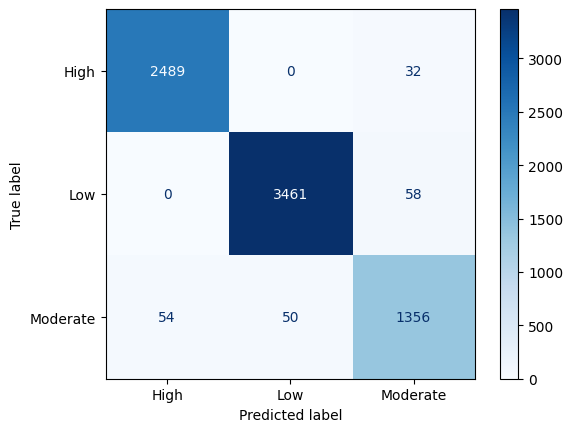

In [19]:
disp = ConfusionMatrixDisplay.from_estimator(
        rf_pipeline,
        X_test,
        y_test,
        cmap=plt.cm.Blues
    )
#print(disp.confusion_matrix)
plt.grid(False)
plt.show()

# Features Importance

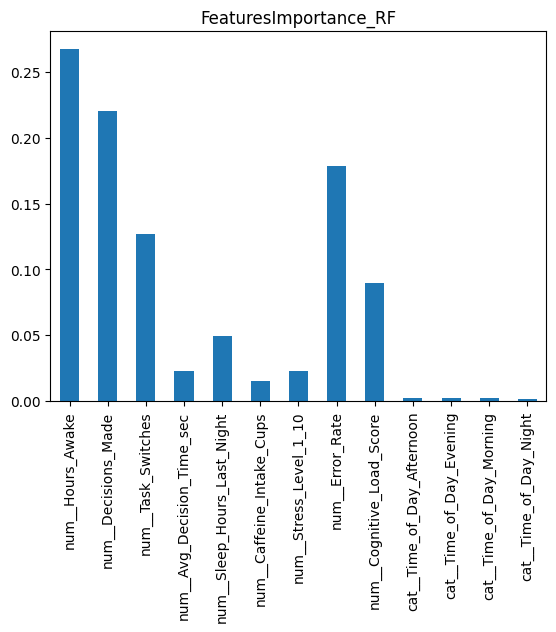

In [20]:
features_importance_rf = pd.Series(rf_pipeline.named_steps["clf"].feature_importances_, index = rf_pipeline.named_steps["preprocess"].get_feature_names_out())
features_importance_rf.plot.bar()
plt.title("FeaturesImportance_RF")
plt.show()

# Interpretation of RF and conclusions

Random Forest achieved a lower macro F1-score (0.97) compared to the logistic regression model (0.99). The confusion matrix shows a similar error pattern, with most misclassifications involving the Moderate class. Feature importance analysis reveals that the same variables identified by the logistic model (e.g., Hours_Awake, Decisions_Made) dominate the predictions. Given the lower F1  and the less straightforward interpretability of the Radom Forest with respect to the Logistic Regression model, if I have to suggest which model to select, I will go for the Logistic Regression Model.